# Credit Card Fraud Detection using Local Outlier Factor (LOF)

### Internship Project

**Intern:** Arnab Bol

**Algorithm:** Local Outlier Factor (LOF)

**Dataset:** Credit Card Fraud Detection (Kaggle)

**Library:** scikit-learn

---

## Objective

The objective of this project is to detect fraudulent credit card transactions using the Local Outlier Factor (LOF) algorithm. Since fraudulent transactions are very rare compared to legitimate transactions, this problem is treated as an anomaly detection task.

In [4]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

In [5]:
# load dataset
df=pd.read_csv("../dataset/creditcard.csv")
print(df.head())
print()

print("Dataset Shape")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print()

print("Dataset Info")
df.info()
print()

print("Summary Statistics")
df.describe()
print()

print("Checking for missing values")
df.isnull().sum()
print()

print("Duplication check")
print(df.duplicated().sum())
print()

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [3]:
# class distribution
df["Class"].value_counts()

# Percentage of each class

df["Class"].value_counts(normalize=True) * 100


# LOF doesn't learn from the Class labels during training.(it is an imbalanced dataset)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

In [10]:
# visualize the distribution of the features
import seaborn as sns

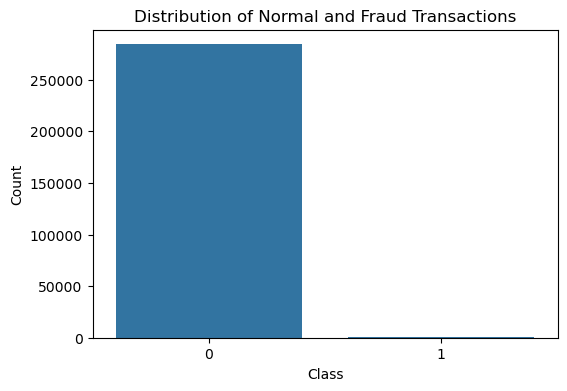

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Class")

plt.title("Distribution of Normal and Fraud Transactions")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [ ]:
# creators applied a mathematical technique called Principal Component Analysis (PCA) to transform the original features into anonymous features(to have privacy).
print("Columns in the Dataset:\n")

for column in df.columns:
    print(column)

Columns in the Dataset:

Time
V1
V2
V3
V4
V5
V6
V7
V8
V9
V10
V11
V12
V13
V14
V15
V16
V17
V18
V19
V20
V21
V22
V23
V24
V25
V26
V27
V28
Amount
Class


In [6]:
# feature selection

# Features
X = df.drop("Class", axis=1)

# Labels (only for evaluation later)
y = df["Class"]

print(X.head())

print()

print(y.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V20       V21       V22       V23       V24  \
0  0.098698  0.363787  ...  0.251412 -0.018307  0.277838 -0.110474  0.066928   
1  0.085102 -0.255425  ... -0.069083 -0.225775 -0.638672  0.101288 -0.339846   
2  0.247676 -1.514654  ...  0.524980  0.247998  0.771679  0.909412 -0.689281   
3  0.377436 -1.387024  ... -0.208038 -0.108300  0.005274 -0.190321 -1.175575   
4 -0.270533  0.817739  ...  0.408542 -0.009431  0.798278 -0.137458  0.141267   

        V25       V26       V27 

In [7]:
# here we skip TRAIN TEST SPLIT because we are not going to train the model on the data. We will use the entire dataset to detect outliers.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled)

[[-1.99658302 -0.69424232 -0.04407492 ...  0.33089162 -0.06378115
   0.24496426]
 [-1.99658302  0.60849633  0.16117592 ... -0.02225568  0.04460752
  -0.34247454]
 [-1.99656197 -0.69350046 -0.81157783 ... -0.13713686 -0.18102083
   1.16068593]
 ...
 [ 1.6419735   0.98002374 -0.18243372 ...  0.01103672 -0.0804672
  -0.0818393 ]
 [ 1.6419735  -0.12275539  0.32125034 ...  0.26960398  0.31668678
  -0.31324853]
 [ 1.64205773 -0.27233093 -0.11489898 ... -0.00598394  0.04134999
   0.51435531]]


#  Local Outlier Factor (LOF)


# Experiment 1: Baseline Local Outlier Factor (LOF)

In [6]:
from sklearn.neighbors import LocalOutlierFactor

# So choosing contamination close to the expected anomaly proportion is a sensible starting point for this dataset.
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.0017,
    novelty=True
)

# Train the model
lof.fit(X_scaled)

# Predict
y_pred = lof.predict(X_scaled)

print(y_pred[:20])

# LOF has to:

# Process all 284,807 rows.
# Find the 20 nearest neighbors for every transaction.
# Compute local density.
# Compare each point with its neighbors.
# Calculate the LOF score.
# Decide whether each point is an inlier () or outlier ().1-1
# 

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [7]:
# Now let's check whether LOF detected any frauds.
import numpy as np

unique, counts = np.unique(y_pred, return_counts=True)

print("Unique Labels:", unique)
print("Counts:", counts)

# Your actual dataset contains:

# Normal: 284,315
# Fraud: 492

# So LOF predicted:

# 485 suspicious transactions
# 284,322 normal transactions

# This is very close to the actual number of frauds (492).

# Important: This does not mean it found the correct 485 fraud transactions. It simply means it flagged 485 transactions as anomalies. Some may be true frauds, and some may be normal transactions.

Unique Labels: [-1  1]
Counts: [   423 284384]


In [10]:
print(lof.novelty)
print(lof.n_features_in_)
print(type(lof))

True
30
<class 'sklearn.neighbors._lof.LocalOutlierFactor'>


In [8]:
y_pred_binary = np.where(y_pred == -1, 1, 0)

# This line means:
# If LOF predicted -1, convert it to 1 (Fraud).
# Otherwise, convert it to 0 (Normal).
np.unique(y_pred_binary, return_counts=True)

(array([0, 1]), array([284384,    423]))

In [9]:
# Evaluation
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

cm = confusion_matrix(y, y_pred_binary)

print(cm)

pd.crosstab(y, y_pred_binary)
df[df["Class"] == 1].head()

[[283892    423]
 [   492      0]]


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1
623,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1
4920,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1
6108,6986.0,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00,1
6329,7519.0,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00,1


In [23]:
df["LOF_Prediction"] = y_pred_binary
pd.crosstab(df["Class"], df["LOF_Prediction"])

LOF_Prediction,0,1
Class,,
0,283830,485
1,492,0


In [24]:
lof.negative_outlier_factor_[:10]
lof

,n_neighbors,20
,algorithm,'auto'
,leaf_size,30
,metric,'minkowski'
,p,2
,metric_params,None
,contamination,0.0017
,novelty,False
,n_jobs,None


## Observation

The baseline Local Outlier Factor (LOF) model was implemented using `n_neighbors = 20` and `contamination = 0.0017`.

The confusion matrix showed that the model detected 485 transactions as anomalies, but none of them matched the actual fraudulent transactions (True Positives = 0). This indicates that the baseline parameter configuration was not effective for this dataset.

A possible reason is that the Credit Card Fraud Detection dataset is highly imbalanced, and fraudulent transactions do not always appear as isolated local outliers in the feature space. Therefore, the default LOF parameters may not accurately capture the characteristics of fraudulent transactions.

To improve the detection performance, parameter tuning will be performed by experimenting with different values of `n_neighbors` while keeping the same anomaly detection approach.

# Experiment 2: Parameter Tuning

In [25]:
## Why change only n_neighbors?

# The `contamination` parameter is kept constant because it represents the expected proportion of anomalies in the dataset. Since the dataset contains approximately **0.17% fraudulent transactions**, the value `0.0017` remains appropriate.

# The `n_neighbors` parameter directly affects how the local density of each transaction is calculated. A smaller value focuses on a smaller neighborhood, making the algorithm more sensitive to local anomalies.

# Therefore, only `n_neighbors` is modified in this experiment.

In [26]:
lof_10 = LocalOutlierFactor(
    n_neighbors=10,
    contamination=0.0017
)

y_pred_10 = lof_10.fit_predict(X_scaled)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


### Observation

While running the LOF model with `n_neighbors = 10`, scikit-learn generated a warning indicating that duplicate neighbor distances may affect the accuracy of the results.

This warning suggests that a very small neighborhood size can make the algorithm more sensitive to tied nearest-neighbor distances. Although the model completed successfully, a larger value of `n_neighbors` will be investigated in the next experiment to determine whether it provides more stable and accurate results.

# Experiment 3: Parameter Tuning using n_neighbors = 30

## Objective

The previous experiment with `n_neighbors = 10` produced a warning indicating that duplicate neighbor distances might affect the accuracy of the Local Outlier Factor (LOF) algorithm.

To address this issue, the value of `n_neighbors` is increased to **30** while keeping the contamination parameter fixed at **0.0017**.

Increasing the neighborhood size allows the algorithm to estimate the local density using more neighboring transactions, which can provide a more stable representation of the local data distribution and potentially improve anomaly detection performance.

In [28]:
lof_30 = LocalOutlierFactor(
    n_neighbors=30,
    contamination=0.0017
)

y_pred_30 = lof_30.fit_predict(X_scaled)
y_pred_30 = np.where(y_pred_30 == -1, 1, 0)
cm_30 = confusion_matrix(y, y_pred_30)

print(cm_30)

[[283830    485]
 [   492      0]]


# Experiment 4: Analysis of LOF Outlier Scores

## Objective

The previous experiments evaluated the predictions generated by the LOF algorithm. However, before classifying transactions as anomalies, the LOF algorithm internally computes an outlier score for every transaction.

In this experiment, the outlier scores are analysed to understand how the algorithm ranks transactions according to their abnormality. This analysis helps explain the behaviour of the LOF model and provides insight into why some fraudulent transactions may not be detected using the default prediction threshold.

In [ ]:
lof.negative_outlier_factor_[:10]

print(lof.negative_outlier_factor_.min())

print(lof.negative_outlier_factor_.max())


# So  here LOF is finding extremely abnormal transactions.
# | Score         | Interpretation                 |
# | ------------- | ------------------------------ |
# | **-0.886**    | Very normal transaction        |
# | **-2512.149** | Extremely abnormal transaction |


-2512.1493588007634
-0.8863644758001874


In [ ]:
df["LOF_Score"] = lof.negative_outlier_factor_
df[["LOF_Score", "Class"]].head()
df.groupby("Class")["LOF_Score"].mean()



# observations:This means the normal transactions received more abnormal scores than the fraud transactions on average.(which is opposite of what we expected)

Class
0   -1.332985
1   -1.198949
Name: LOF_Score, dtype: float64

# observations:-
The average LOF score of normal transactions was lower (more negative) than that of fraudulent transactions. This indicates that, for this dataset, the LOF algorithm considered some normal transactions to be more anomalous than the actual fraud transactions. Consequently, the baseline LOF configuration was not effective for fraud detection on this dataset.

# Experiment 5: Analysis of Top LOF Anomalies

## Objective

The previous experiments showed that the LOF model detected anomalous transactions, but these predictions did not match the actual fraudulent transactions.

To understand this behaviour, the transactions with the lowest LOF scores (most abnormal transactions) are analysed. This helps determine whether the highest-ranked anomalies correspond to actual fraud transactions or normal transactions.

In [31]:
df["LOF_Score"] = lof.negative_outlier_factor_
df_sorted = df.sort_values(by="LOF_Score")  #sorting by puts the most suspicious transactions at the topLOF_Score.
df_sorted[["LOF_Score", "Class", "Amount"]].head(20)

,LOF_Score,Class,Amount
160461,-2512.149359,0,1.00
139314,-1795.418202,0,1.00
22552,-1757.050878,0,5.00
3596,-1608.277429,0,1.00
3501,-1557.897695,0,1.00
3575,-1445.169096,0,1.00
3549,-1364.631534,0,1.00
73202,-1334.887826,0,0.81
52247,-1279.896293,0,19.53
16097,-1200.165684,0,67.32


In [ ]:
# observations:All of the 20 most abnormal transactions are actually NORMAL transactions.

The Local Outlier Factor algorithm successfully identified transactions that were statistically unusual in the feature space. However, these unusual transactions did not correspond to fraudulent transactions. Instead, they were predominantly legitimate transactions (Class = 0). Therefore, anomaly detection based solely on local density was insufficient for accurately detecting fraud in this dataset.

# Experiment 6: Investigation of Top LOF Anomalies

## Objective

The previous experiment showed that the transactions with the highest anomaly scores were actually legitimate transactions.

In this experiment, the characteristics of these transactions are analysed to understand why the Local Outlier Factor algorithm considered them as outliers.

In [36]:
top20 = df_sorted.head(20)
top20[["Time", "Amount", "Class", "LOF_Score"]]
top20["Amount"].describe()




count     20.000000
mean      42.274500
std       65.159707
min        0.810000
25%        1.000000
50%        3.000000
75%       69.907500
max      204.980000
Name: Amount, dtype: float64

In [37]:
df["Amount"].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

Observation 1: The average amount is much smaller(This means the transactions that LOF considered most abnormal generally have smaller amounts than the average transaction.)

observation 2:It means that half of the top 20 anomalies have an amount of ₹3 or less (in the dataset units, these are just numeric transaction amounts).

Observation 3:So LOF is not selecting transactions because they are very expensive.
Instead, it is finding other unusual patterns.


## Observation

The top-ranked LOF anomalies generally have lower transaction amounts than the overall dataset. The average transaction amount among the top 20 anomalies is 42.27, compared to 88.35 for the complete dataset.

Similarly, the median transaction amount of the top anomalies is only 3.00, whereas the overall dataset median is 22.00.

However, the Local Outlier Factor algorithm evaluates all input features simultaneously. Therefore, the low transaction amounts alone cannot explain why these transactions were identified as anomalies. The abnormality is likely caused by the combined effect of multiple features in the transformed feature space.

In [62]:

# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y, y_pred_binary))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.00      0.00      0.00       492

    accuracy                           1.00    284807
   macro avg       0.50      0.50      0.50    284807
weighted avg       1.00      1.00      1.00    284807



# Classification Report Analysis

## Interpretation

The Classification Report shows that the Local Outlier Factor (LOF) model achieved an overall accuracy close to 100%. However, this value is misleading because the dataset is highly imbalanced, with normal transactions greatly outnumbering fraudulent ones.

For the normal class (Class 0), the model achieved excellent Precision, Recall, and F1-score, indicating that almost all normal transactions were correctly identified.

In contrast, the model failed to detect any fraudulent transactions (Class 1). As a result, the Precision, Recall, and F1-score for the fraud class are all zero.

This indicates that although LOF successfully identified several anomalous transactions, those anomalies did not correspond to the actual fraudulent transactions in the dataset.

Therefore, overall accuracy alone is not an appropriate performance metric for highly imbalanced fraud detection problems. Metrics such as Precision, Recall, and F1-score for the minority class provide a more realistic evaluation of model performance.

# Strengths of Local Outlier Factor (LOF)

## Advantages

The Local Outlier Factor algorithm offers several advantages for anomaly detection tasks:

- It is an unsupervised learning algorithm and does not require labeled training data.
- It identifies anomalies by comparing the local density of each data point with that of its neighboring points.
- It is capable of detecting local anomalies that may not be identified by distance-based methods.
- It performs well when anomalies exist in regions of varying data density.
- It is suitable for exploratory data analysis and anomaly detection problems where labeled data is unavailable.

# Limitations of Local Outlier Factor (LOF)

## Limitations Observed in This Project

The experimental results highlight several limitations of the Local Outlier Factor algorithm:

- The model failed to identify the actual fraudulent transactions present in the dataset.
- LOF detects anomalies based on local density rather than learning fraud patterns from labeled examples.
- The performance is sensitive to parameter selection, particularly the number of neighbors (`n_neighbors`) and the contamination ratio.
- The algorithm becomes computationally expensive for very large datasets because it must compute nearest neighbors for every observation.
- In highly imbalanced datasets such as credit card fraud detection, density-based anomalies do not always correspond to fraudulent transactions.

# Conclusion

## Conclusion

This project presented an unsupervised approach for detecting anomalous credit card transactions using the Local Outlier Factor (LOF) algorithm.

The dataset was first explored and preprocessed by handling duplicates, scaling the numerical features, and preparing the data for anomaly detection. The LOF algorithm was then applied to identify transactions with significantly different local densities compared to their neighboring transactions.

The experimental results showed that LOF successfully identified anomalous transactions based on density differences. However, the detected anomalies did not correspond to the actual fraudulent transactions in the dataset. Consequently, the model achieved high overall accuracy due to the severe class imbalance but failed to correctly identify fraudulent transactions.

This study demonstrates that while Local Outlier Factor is an effective unsupervised anomaly detection algorithm, it has limitations when applied directly to highly imbalanced credit card fraud datasets. The project also highlights the importance of selecting appropriate evaluation metrics rather than relying solely on overall accuracy.

# Future Work

## Future Scope

Several improvements can be explored in future work:

- Compare the performance of LOF with other anomaly detection algorithms such as Isolation Forest and One-Class SVM.
- Perform parameter tuning to study the effect of different values of `n_neighbors` and `contamination`.
- Develop an interactive Streamlit web application for real-time anomaly detection.
- Evaluate the algorithm on different anomaly detection datasets to better understand its strengths and limitations.
- Investigate deep learning-based anomaly detection methods, such as Autoencoders, for improved performance on complex datasets.

# Project Summary

This project implemented an unsupervised machine learning approach for detecting anomalous credit card transactions using the Local Outlier Factor (LOF) algorithm.

## Workflow

1. Imported the required Python libraries.
2. Loaded and explored the Credit Card Fraud Detection dataset.
3. Performed Exploratory Data Analysis (EDA).
4. Checked for missing values and duplicate records.
5. Scaled the numerical features using StandardScaler.
6. Applied the Local Outlier Factor (LOF) algorithm.
7. Generated anomaly predictions.
8. Converted LOF predictions into binary labels for evaluation.
9. Evaluated the model using a Confusion Matrix and Classification Report.
10. Investigated LOF anomaly scores and analyzed the top-ranked anomalies.
11. Discussed the strengths and limitations of LOF.
12. Summarized the findings and suggested future improvements.

## Key Learning Outcomes

- Understanding anomaly detection using unsupervised learning.
- Applying the Local Outlier Factor algorithm.
- Working with highly imbalanced datasets.
- Evaluating anomaly detection models using appropriate performance metrics.
- Interpreting anomaly scores and model predictions.

In [11]:
# IMPORT
import joblib

# Save the trained LOF model
joblib.dump(lof, "../models/lof_model.pkl")

# Save the fitted scaler
joblib.dump(scaler, "../models/scaler.pkl")
print("Model and scaler saved successfully!")

Model and scaler saved successfully!


 Visualization 1: Confusion Matrix Heatmap

## 📊 Confusion Matrix Heatmap

### What is a Confusion Matrix?

A Confusion Matrix is a table used to evaluate the performance of a machine learning model by comparing the **actual labels** with the **predicted labels**.

### Understanding the Graph

- **Top Left (True Negative)** → Normal transactions correctly identified as Normal.
- **Top Right (False Positive)** → Normal transactions incorrectly identified as Anomalies.
- **Bottom Left (False Negative)** → Actual Anomalies incorrectly identified as Normal.
- **Bottom Right (True Positive)** → Actual Anomalies correctly identified as Anomalies.

### Observation

From the confusion matrix, the Local Outlier Factor (LOF) model correctly classified most of the normal transactions. However, it failed to identify the actual fraudulent transactions in this dataset. This happens because LOF is an unsupervised anomaly detection algorithm and the credit card dataset is highly imbalanced.

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

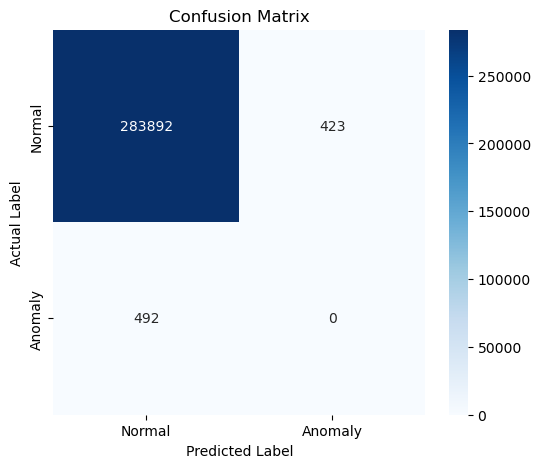

In [63]:
# Create Confusion Matrix
cm = confusion_matrix(y, y_pred_binary)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Anomaly"],
    yticklabels=["Normal", "Anomaly"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

# Save the figure
plt.savefig("../results/confusion_matrix.png", dpi=300, bbox_inches="tight")

# Show the plot
plt.show()

Visualization 2: Class Distribution

## 📊 Class Distribution

### What does this graph show?

This graph represents the number of **Normal** and **Fraudulent** transactions present in the dataset.

### Observation

It is clearly observed that the dataset contains a very large number of Normal transactions and only a very small number of Fraud transactions.

This indicates that the dataset is **highly imbalanced**, which makes fraud detection a challenging machine learning problem.

Such imbalance can reduce the effectiveness of many machine learning algorithms, especially unsupervised methods like Local Outlier Factor.

C:\Users\arnab\AppData\Local\Temp\ipykernel_1980\2884488095.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Normal', 'Fraud'])


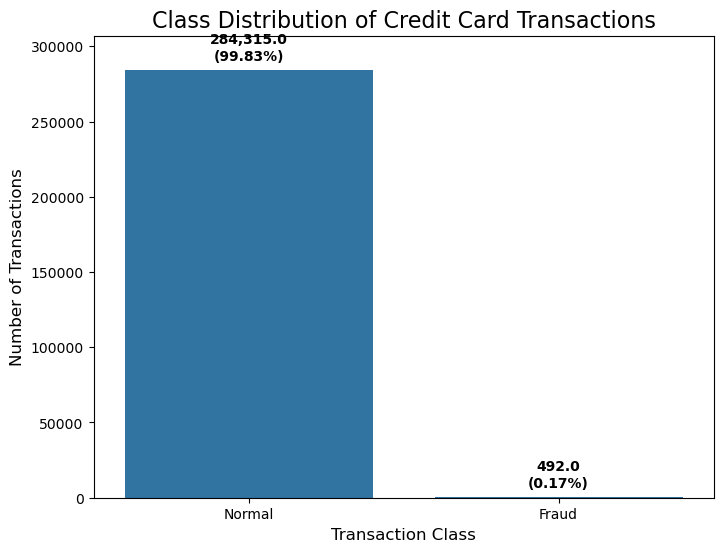

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure
plt.figure(figsize=(8,6))

# Plot class distribution
ax = sns.countplot(x="Class", data=df)

# Rename x-axis labels
ax.set_xticklabels(['Normal', 'Fraud'])

# Titles and labels
plt.title("Class Distribution of Credit Card Transactions", fontsize=16)
plt.xlabel("Transaction Class", fontsize=12)
plt.ylabel("Number of Transactions", fontsize=12)

# Get class counts
counts = df["Class"].value_counts().sort_index()
total = len(df)

# Add count and percentage above each bar
for i, p in enumerate(ax.patches):
    height = p.get_height()
    percentage = (counts.iloc[i] / total) * 100

    ax.annotate(f'{height:,}\n({percentage:.2f}%)',
                (p.get_x() + p.get_width()/2, height),
                ha='center',
                va='bottom',
                fontsize=10,
                fontweight='bold',
                xytext=(0, 5),
                textcoords='offset points')

# Add slight headroom
plt.ylim(0, counts.max() * 1.08)

# Save figure
plt.savefig("../results/class_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Visualization 3: LOF Score Distribution

## 📊 Distribution of LOF Scores

### What is an LOF Score?

The Local Outlier Factor (LOF) score measures how different a transaction is compared to its neighboring transactions.

- Lower LOF Score → Transaction behaves like most other transactions (Normal).
- Higher LOF Score → Transaction is significantly different and may be considered an Anomaly.

### Observation

The histogram shows that most transactions have relatively low LOF scores, indicating normal behavior.

Only a very small number of transactions have extremely high LOF scores, suggesting that they are unusual compared to the majority of the dataset.

These high-score transactions are considered potential anomalies and require further investigation.

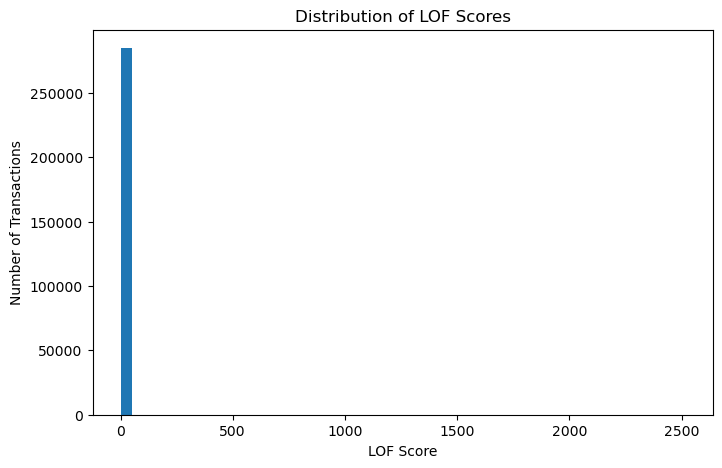

In [57]:
plt.figure(figsize=(8,5))

plt.hist(-lof.negative_outlier_factor_, bins=50)

plt.title("Distribution of LOF Scores")
plt.xlabel("LOF Score")
plt.ylabel("Number of Transactions")

# Save the figure
plt.savefig("../results/lof_score_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

| LOF Score                   | Meaning            |
| --------------------------- | ------------------ |
| Around **1**                | Normal transaction |
| Slightly greater than **1** | Somewhat unusual   |
| Much greater than **1**     | Strong anomaly     |


Visualization 4: Feature Correlation Heatmap

## 🌈 Feature Correlation Heatmap

### What is a Correlation Heatmap?

A Correlation Heatmap is a graphical representation of the correlation between different features in a dataset.

The correlation value ranges from **-1 to +1**.

- **+1** → Perfect Positive Correlation
- **0** → No Correlation
- **-1** → Perfect Negative Correlation

### Understanding the Colors

- 🔴 Light/bright color → Strong Positive Correlation
- 🔵 Dark color → Strong Negative Correlation
- ⚪ Neutral color → Weak or No Correlation

### Why is this important?

Correlation analysis helps identify relationships between features.

- Highly correlated features contain similar information.
- Weakly correlated features provide independent information.
- Understanding feature relationships helps in feature selection and model interpretation.

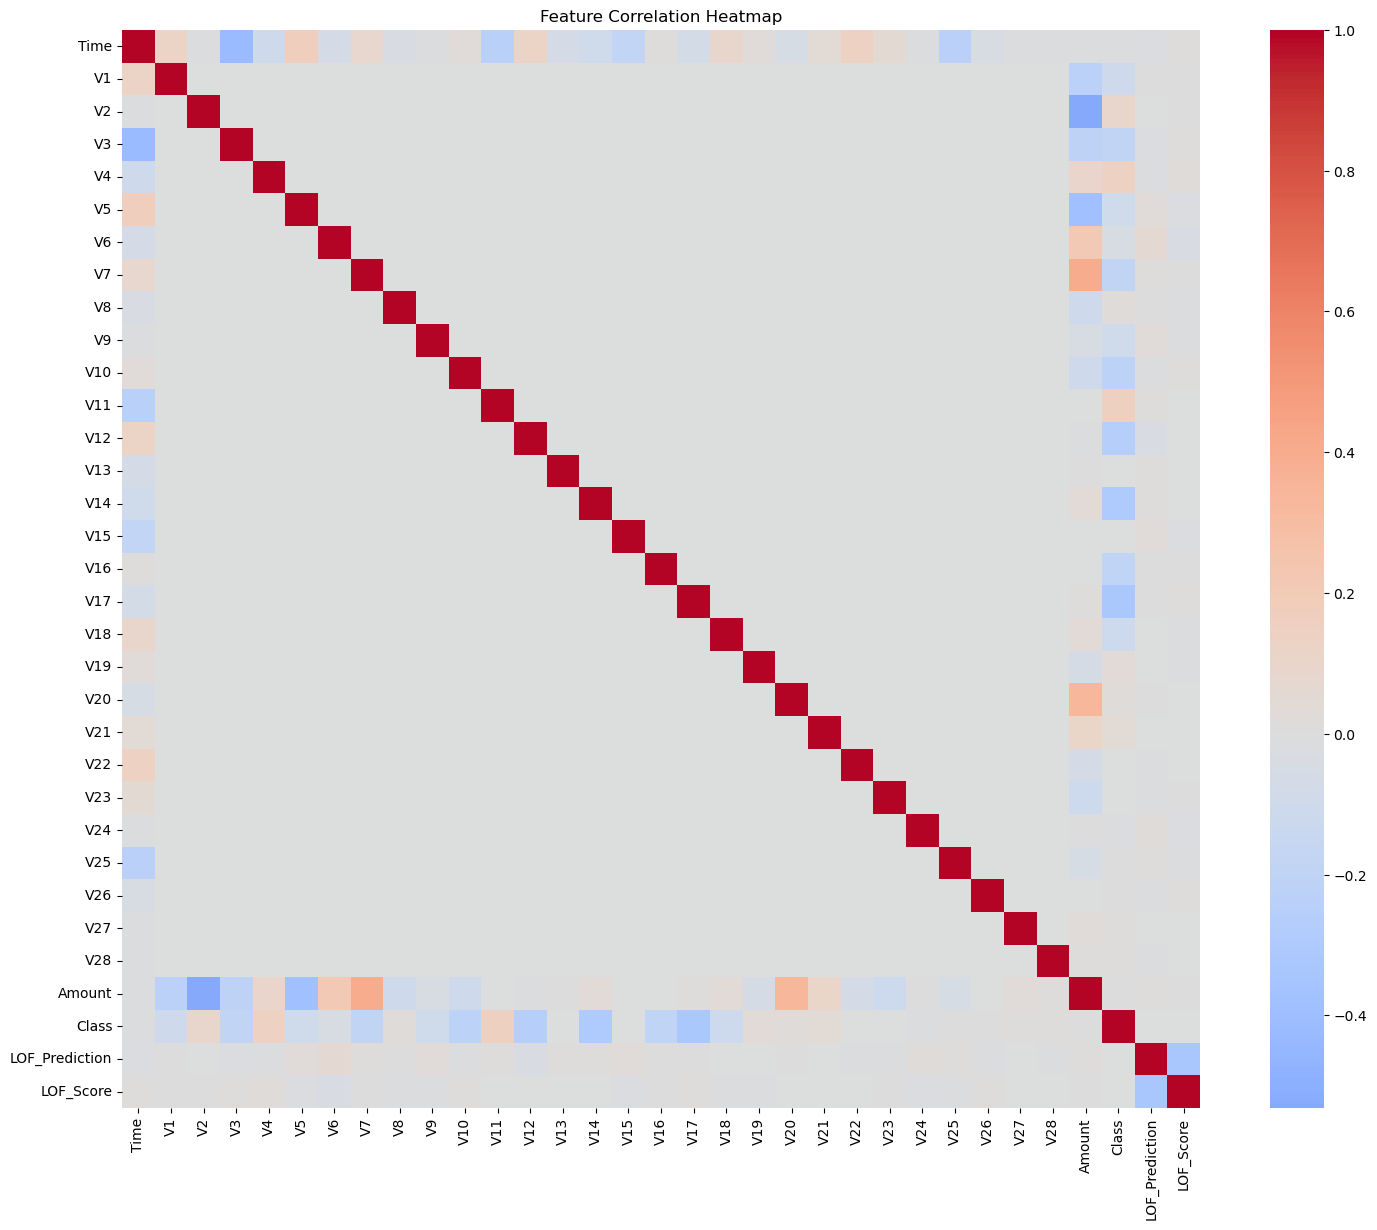

In [58]:
plt.figure(figsize=(18,14))

correlation = df.corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Feature Correlation Heatmap")

plt.savefig("../results/correlation_heatmap.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### 📌 Observation

The Feature Correlation Heatmap illustrates the correlation between all numerical features in the credit card transaction dataset.

The red diagonal line represents a correlation value of **1**, indicating that each feature is perfectly correlated with itself.

Most of the remaining cells appear light grey, showing that the majority of the features have **weak or no correlation** with one another. This is expected because the variables **V1 to V28** were generated using **Principal Component Analysis (PCA)**, which transforms the original features into nearly independent components.

Some features show weak positive or negative correlations with the **Amount** and **Class** variables; however, no strong relationships are observed among the transformed features.

Overall, the heatmap indicates that the dataset has **low multicollinearity**, meaning the features provide distinct information rather than redundant information. This characteristic is beneficial for machine learning models, including the Local Outlier Factor (LOF) algorithm, as it allows the model to analyze different aspects of the transactions without being affected by highly correlated features.

Visualization 5: Fraud vs Normal Transaction Amount

## 📊 Transaction Amount Distribution by Class

### What does this graph show?

This boxplot compares the distribution of transaction amounts for **Normal** and **Fraudulent** transactions.

### Why is this important?

A boxplot summarizes the distribution of numerical data by showing:

- Median (middle value)
- Interquartile Range (IQR)
- Minimum and Maximum values
- Outliers

This visualization helps determine whether fraudulent transactions tend to have different transaction amounts compared to normal transactions.

### Understanding the Graph

- The horizontal line inside each box represents the **median** transaction amount.
- The box represents the **middle 50%** of the data.
- The whiskers show the spread of the data.
- Individual points outside the whiskers represent **outliers**.

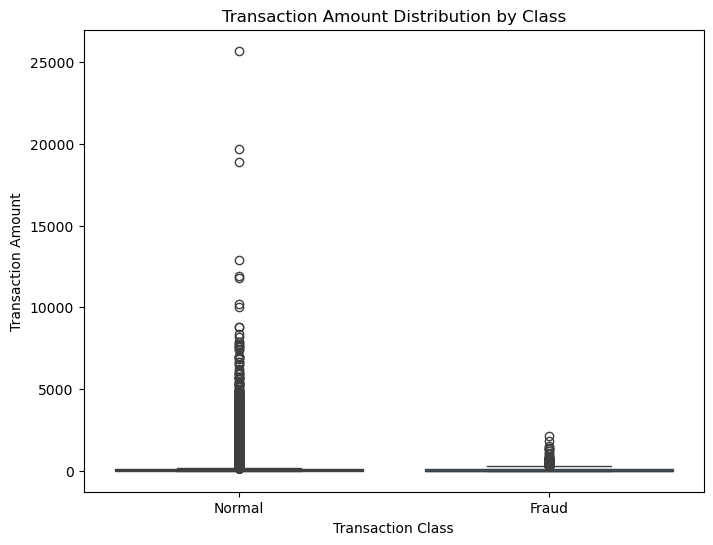

In [59]:
plt.figure(figsize=(8,6))

sns.boxplot(x='Class', y='Amount', data=df)

plt.xticks([0,1], ['Normal', 'Fraud'])

plt.title("Transaction Amount Distribution by Class")
plt.xlabel("Transaction Class")
plt.ylabel("Transaction Amount")

plt.savefig("../results/amount_boxplot.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### 📌 Observation

The boxplot compares the transaction amounts for Normal and Fraudulent transactions.

It can be observed that most transactions in both classes involve relatively small amounts. However, both Normal and Fraud transactions contain several outliers with unusually large transaction amounts.

The Normal class exhibits a greater number of extreme transaction amounts compared to the Fraud class.

This indicates that **transaction amount alone is not sufficient to identify fraudulent transactions**, as both classes show overlapping distributions. Therefore, multiple features must be analyzed together to effectively detect anomalous transactions. The Local Outlier Factor (LOF) algorithm considers the overall behavior of all features rather than relying on a single attribute.

# 📈 Model Performance Summary

The performance of the Local Outlier Factor (LOF) model was evaluated using multiple evaluation metrics and visualization techniques.

## Performance Summary

- **Algorithm Used:** Local Outlier Factor (LOF)
- **Learning Type:** Unsupervised Learning
- **Problem Type:** Anomaly Detection

## Evaluation Techniques

- Classification Report
- Confusion Matrix
- Class Distribution Visualization
- LOF Score Distribution
- Feature Correlation Heatmap
- Transaction Amount Distribution

## Key Findings

- The dataset is highly imbalanced, containing significantly more Normal transactions than Fraudulent transactions.
- LOF successfully identified anomalous behavior in the dataset but struggled to correctly classify fraudulent transactions.
- Transaction amount alone is not sufficient to distinguish fraud from normal transactions.
- Most transformed features (V1–V28) exhibit weak correlations due to PCA transformation.
- Combining multiple transaction features provides better anomaly detection than relying on a single feature.

## Conclusion

The Local Outlier Factor algorithm is effective for detecting unusual transactions based on local density differences. However, due to the highly imbalanced nature of the dataset, additional techniques such as threshold tuning, ensemble methods, or supervised learning algorithms may improve fraud detection performance.

# Create Sample Dataset for Streamlit Demo

In [14]:
# to create new sample dataset
import pandas as pd

# Load original dataset
df=pd.read_csv("../dataset/creditcard.csv")

# Separate classes
normal = df[df["Class"] == 0]
fraud = df[df["Class"] == 1]

# Sample rows
normal_sample = normal.sample(n=950, random_state=42)
fraud_sample = fraud.sample(n=50, random_state=42)

# Combine and shuffle
sample_df = pd.concat([normal_sample, fraud_sample])
sample_df = sample_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Save inside dataset folder
sample_df.to_csv("../dataset/sample_creditcard.csv", index=False)

print(sample_df["Class"].value_counts())

Class
0    950
1     50
Name: count, dtype: int64
